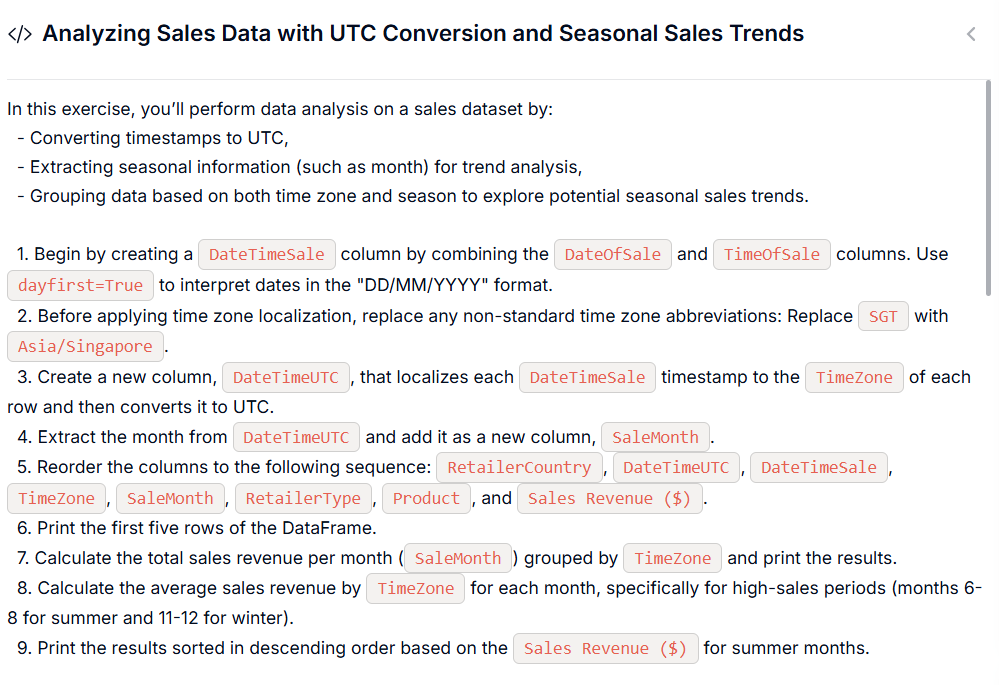

In [11]:
import pandas as pd

# Load data with SaleID as index
data = pd.read_csv('Sales-products-tz-mod.csv', index_col='SaleID')
sales_data = data.copy()

# Step 1: Combine 'DateOfSale' and 'TimeOfSale' into 'DateTimeSale' with dayfirst=True
sales_data['DateTimeSale'] = pd.to_datetime(sales_data['DateOfSale'] +" "+ sales_data['TimeOfSale'], dayfirst=True)

# Replace 'SGT' with 'Asia/Singapore' for timezone consistency
sales_data['TimeZone'] = sales_data['TimeZone'].replace({'SGT':'Asia/Singapore'})

# Step 2: Create 'DateTimeUTC' column with UTC-converted timestamps
'''
Using the lambda function rather the def as function is only used once inline.
row is the argument or input to the function.
axis = 1 means perform the operation across rows instead of columns hence "lambda row:"
'''
sales_data['DateTimeUTC'] = sales_data.apply(lambda row: row['DateTimeSale'].tz_localize(row['TimeZone']).tz_convert('UTC'), axis=1)

# Step 3: Extract month from 'DateTimeUTC' and add it as 'SaleMonth'
sales_data['SaleMonth'] = sales_data['DateTimeUTC'].dt.month

# Step 4: Reorder columns
column_names_reordered = ['RetailerCountry', 'DateTimeUTC', 'DateTimeSale', 'TimeZone', 'SaleMonth', 'RetailerType', 'Product', 'Sales Revenue ($)']
sales_data = sales_data[column_names_reordered]

# Step 5: Print first 5 rows of the reordered DataFrame
print("Reordered DataFrame with 'DateTimeUTC' and 'SaleMonth':")
print(sales_data.head(5))

# Step 6: Calculate total sales revenue per month grouped by 'TimeZone'
total_revenue_by_month = sales_data.groupby(['TimeZone', 'SaleMonth'])['Sales Revenue ($)'].sum()
print("\nTotal Sales Revenue by TimeZone and Month:")
print(total_revenue_by_month)

# Step 7: Average sales revenue for summer (6-8) and winter (11-12) months by 'TimeZone'
seasonal_sales = sales_data[sales_data['SaleMonth'].isin([6, 7, 8, 11, 12])]
average_revenue_seasonal = seasonal_sales.groupby(['TimeZone', 'SaleMonth'])['Sales Revenue ($)'].mean()
print("\nAverage Sales Revenue for Summer and Winter Months by TimeZone:")
print(average_revenue_seasonal)

# Step 8: Print results for summer months sorted by revenue in descending order
summer_sales = seasonal_sales[seasonal_sales['SaleMonth'].isin([6, 7, 8])]
sorted_summer_sales = summer_sales.groupby(['TimeZone', 'SaleMonth'])['Sales Revenue ($)'].mean().sort_values(ascending=False)
print("\nSorted Average Sales Revenue for Summer Months by TimeZone:")
print(sorted_summer_sales)

Reordered DataFrame with 'DateTimeUTC' and 'SaleMonth':
         RetailerCountry               DateTimeUTC        DateTimeSale  \
SaleID                                                                   
SaleID_1   United States 2020-01-07 04:20:56+00:00 2020-01-06 23:20:56   
SaleID_2   United States 2020-02-05 22:27:08+00:00 2020-02-05 17:27:08   
SaleID_3   United States 2020-10-30 14:04:43+00:00 2020-10-30 09:04:43   
SaleID_4   United States 2020-11-13 09:25:06+00:00 2020-11-13 04:25:06   
SaleID_5           Italy 2020-12-06 10:15:47+00:00 2020-12-06 11:15:47   

         TimeZone  SaleMonth   RetailerType                    Product  \
SaleID                                                                   
SaleID_1      EST          1  Outdoors Shop  TrailChef Deluxe Cook Set   
SaleID_2      EST          2  Outdoors Shop     TrailChef Double Flame   
SaleID_3      EST         10  Outdoors Shop                  Star Dome   
SaleID_4      EST         11  Outdoors Shop            

In [14]:
# Lambda quick example
double = lambda x: x * 2
print(double(7))  # Output: 14

14
